In [15]:
import tensorflow as tf
print("Name: Piriyadharshini N\nRoll no.: 24BAD086\n")
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

Name: Piriyadharshini N
Roll no.: 24BAD086

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [4]:
from google.colab import files

uploaded = files.upload()

Saving train.zip to train.zip


In [5]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


cat: 95 images
dog: 180 images

cat
Total: 95
Train: 66
Validation: 14
Test: 15

dog
Total: 180
Train: 125
Validation: 27
Test: 28
Found 191 files belonging to 2 classes.
Found 41 files belonging to 2 classes.
Found 43 files belonging to 2 classes.

Classes: ['cat', 'dog']


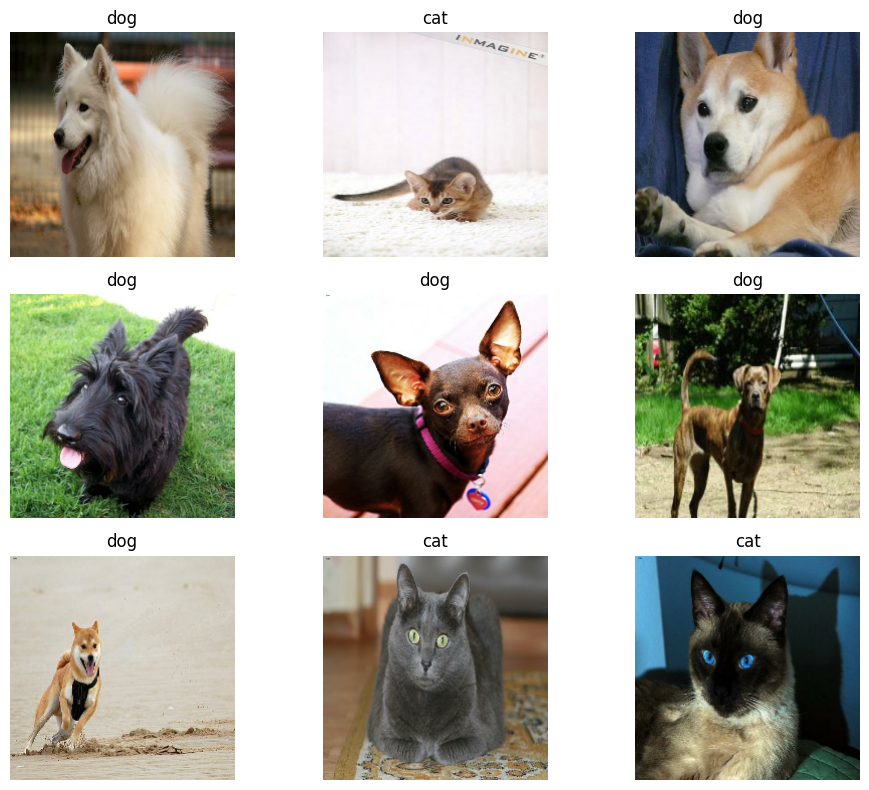


Dataset preparation completed!


In [10]:
import shutil
import random
random.seed(SEED)

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

SOURCE_DIR = "/content/dataset"
SPLIT_DIR = "/content/split_dataset"
CLASSES = ["cat", "dog"]

# Check original dataset
for class_name in CLASSES:
    path = os.path.join(SOURCE_DIR, class_name)
    images = [
        f for f in os.listdir(path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    print(f"{class_name}: {len(images)} images")

# Remove old split dataset
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

# Create folders
for split in ["train", "val", "test"]:
    for class_name in CLASSES:
        os.makedirs(
            os.path.join(SPLIT_DIR, split, class_name),
            exist_ok=True
        )

# Split dataset
random.seed(SEED)

for class_name in CLASSES:
    source_path = os.path.join(SOURCE_DIR, class_name)

    images = [
        f for f in os.listdir(source_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(images)

    total = len(images)
    train_end = int(0.70 * total)
    val_end = train_end + int(0.15 * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Copy images
    for image in train_images:
        shutil.copy(
            os.path.join(source_path, image),
            os.path.join(SPLIT_DIR, "train", class_name, image)
        )

    for image in val_images:
        shutil.copy(
            os.path.join(source_path, image),
            os.path.join(SPLIT_DIR, "val", class_name, image)
        )

    for image in test_images:
        shutil.copy(
            os.path.join(source_path, image),
            os.path.join(SPLIT_DIR, "test", class_name, image)
        )

    print(f"\n{class_name}")
    print(f"Total: {total}")
    print(f"Train: {len(train_images)}")
    print(f"Validation: {len(val_images)}")
    print(f"Test: {len(test_images)}")

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Get class names
class_names = train_ds.class_names

print("\nClasses:", class_names)

# Display sample images
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

# Optimize loading
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("\nDataset preparation completed!")

In [11]:
# Import ResNet-50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Load pre-trained ResNet-50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pre-trained layers
base_model.trainable = False

# Build model
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
model.summary()

# Train model
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5759 - loss: 0.7840 - val_accuracy: 0.7317 - val_loss: 0.6282
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.6597 - loss: 0.7023 - val_accuracy: 0.7073 - val_loss: 0.6120
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.6283 - loss: 0.6409 - val_accuracy: 0.7317 - val_loss: 0.6355
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.7016 - loss: 0.5940 - val_accuracy: 0.6585 - val_loss: 0.6235
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.6440 - loss: 0.6134 - val_accuracy: 0.7073 - val_loss: 0.6380
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.6597 - loss: 0.5716 - val_accuracy: 0.6585 - val_loss: 0.5957
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.7435 - loss: 0.5408 - val_accuracy: 0.6585 - val_loss: 0.5900
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.6911 - loss: 0.5772 - val_accuracy: 0.6341 - val_loss: 0

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step - accuracy: 0.7442 - loss: 0.5820

Test Results
Test Loss: 0.5820341110229492
Test Accuracy: 0.7441860437393188
Test Accuracy (%): 74.41860437393188


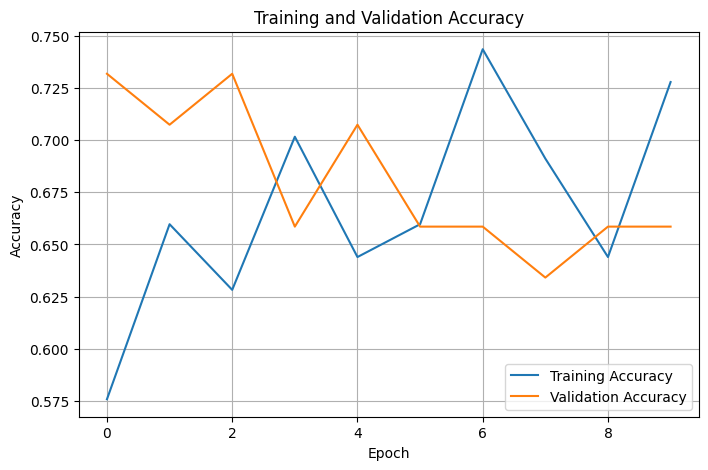

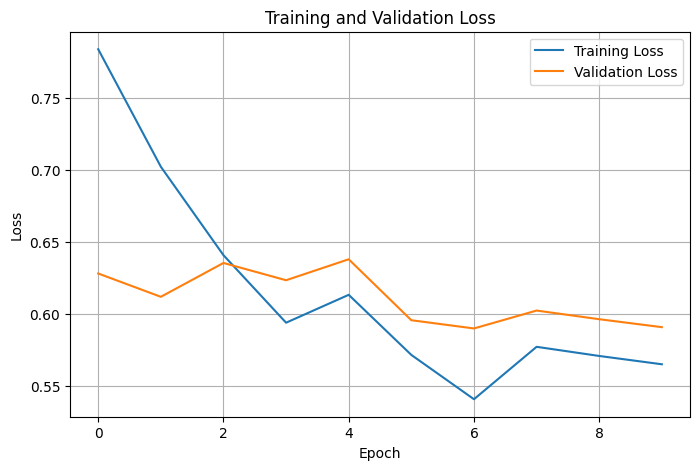


Final Training Results
Training Accuracy: 72.7748692035675 %
Validation Accuracy: 65.85366129875183 %
Training Loss: 0.5651005506515503
Validation Loss: 0.5908787250518799


In [12]:
# Test the model
test_loss, test_accuracy = model.evaluate(test_ds)

print("\nTest Results")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Display final training results
print("\nFinal Training Results")
print("Training Accuracy:",
      history.history["accuracy"][-1] * 100, "%")

print("Validation Accuracy:",
      history.history["val_accuracy"][-1] * 100, "%")

print("Training Loss:",
      history.history["loss"][-1])

print("Validation Loss:",
      history.history["val_loss"][-1])

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Hugging Face model loaded successfully!


Saving Persian_117_jpg.rf.30b82f0e3d2ae0115aaf62d09e792f1f.jpg to Persian_117_jpg.rf.30b82f0e3d2ae0115aaf62d09e792f1f.jpg


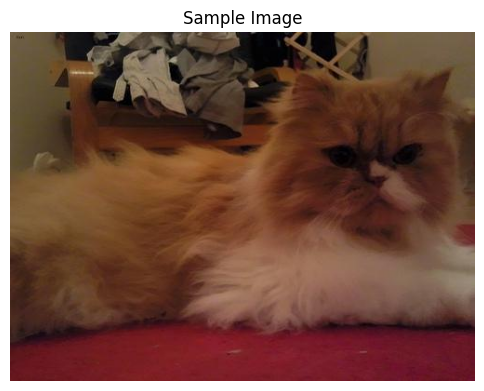


Hugging Face Predictions:
Persian cat : 99.51%
Angora, Angora rabbit : 0.05%
Pomeranian : 0.03%
tabby, tabby cat : 0.02%
Pekinese, Pekingese, Peke : 0.02%


In [13]:
# Install Hugging Face Transformers
!pip install -q transformers

# Import libraries
from transformers import pipeline
from PIL import Image
from google.colab import files

# Load pre-trained vision model
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

print("Hugging Face model loaded successfully!")

# Upload a sample image
uploaded = files.upload()

# Get image path
image_path = list(uploaded.keys())[0]

# Open image
image = Image.open(image_path).convert("RGB")

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Sample Image")
plt.show()

# Perform image classification
results = classifier(image)

# Display predictions
print("\nHugging Face Predictions:")

for result in results[:5]:
    print(
        f"{result['label']} : "
        f"{result['score'] * 100:.2f}%"
    )

In [14]:
# Prepare image for ResNet-50
img = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

# ResNet-50 prediction
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

# Display result
print("ResNet-50 Prediction")
print("--------------------")
print("Actual Class      :", class_name)
print("Predicted Class   :", predicted_class)
print("Confidence        :", f"{confidence:.2f}%")

print("\nHugging Face Prediction")
print("-----------------------")
for result in results[:3]:
    print(
        result["label"],
        ":",
        f"{result['score'] * 100:.2f}%"
    )

ResNet-50 Prediction
--------------------
Actual Class      : dog
Predicted Class   : cat
Confidence        : 78.27%

Hugging Face Prediction
-----------------------
Persian cat : 99.51%
Angora, Angora rabbit : 0.05%
Pomeranian : 0.03%
